In [1]:
# Install required packages (if not already installed)
!pip install -q scikit-learn xgboost pandas numpy matplotlib seaborn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
import joblib
import warnings
import re
import random
from collections import Counter
from typing import Dict, List, Tuple, Any
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Setup complete!")

Setup complete!


In [3]:
# Mount Google Drive and set path
from google.colab import drive
drive.mount('/content/drive')

# Update this path to match where you saved MASTER.csv in your Drive
DATA_PATH = '/content/drive/MyDrive/MASTER_NEW.csv'

# Load the dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"\nMethodology distribution:")
print(df['detailed_methodology'].value_counts())
print(f"\nClass balance:")
print(df['detailed_methodology'].value_counts(normalize=True))

# Load the saved split indices for consistency
split_indices = joblib.load('/content/drive/MyDrive/split_indices_v7.pkl')
print(f"\nLoaded split indices from discipline classifier")
print(f"Train size: {len(split_indices['train_indices'])}")
print(f"Val size: {len(split_indices['val_indices'])}")
print(f"Test size: {len(split_indices['test_indices'])}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (26944, 6)

Methodology distribution:
detailed_methodology
ALGO       7133
CASE       5882
SYST       4613
REVW       3086
EXPT       2113
PERF       2086
ANAL       1302
UNKNOWN     729
Name: count, dtype: int64

Class balance:
detailed_methodology
ALGO       0.264734
CASE       0.218305
SYST       0.171207
REVW       0.114534
EXPT       0.078422
PERF       0.077420
ANAL       0.048322
UNKNOWN    0.027056
Name: proportion, dtype: float64

Loaded split indices from discipline classifier
Train size: 18916
Val size: 5299
Test size: 6553


In [4]:
def preprocess_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Keep alphanumeric, spaces, and basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s\.\,\!\?\-]', ' ', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Combine title and abstract for better context
df['combined_text'] = df['title'].fillna('') + ' ' + df['abstract'].fillna('')
df['processed_text'] = df['combined_text'].apply(preprocess_text)

# Remove any rows with empty processed text
df = df[df['processed_text'].str.len() > 10].copy()
print(f"Dataset shape after preprocessing: {df.shape}")

Dataset shape after preprocessing: (26944, 8)


In [6]:
# Use the same splits as discipline classifier
X = df['processed_text'].values
y = df['detailed_methodology'].values  # THIS IS THE KEY DIFFERENCE - using methodology labels

# Extract train, val, test using saved indices
X_train = X[split_indices['train_indices']]
y_train = y[split_indices['train_indices']]

X_val = X[split_indices['val_indices']]
y_val = y[split_indices['val_indices']]

X_test = X[split_indices['test_indices']]
y_test = y[split_indices['test_indices']]

print(f"Train set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# Verify class distribution
print("\nClass distribution in splits:")
for name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    dist = pd.Series(y_split).value_counts(normalize=True).sort_index()
    print(f"{name}: {dist.to_dict()}")

Train set size: 18916 (70.2%)
Validation set size: 5299 (19.7%)
Test set size: 6553 (24.3%)

Class distribution in splits:
Train: {'ALGO': 0.2580355254810742, 'ANAL': 0.04847747938253331, 'CASE': 0.22325015859589764, 'EXPT': 0.07691901036159865, 'PERF': 0.07681327976316346, 'REVW': 0.11693804186931699, 'SYST': 0.17339818143370692, 'UNKNOWN': 0.026168323112708818}
Val: {'ALGO': 0.2613700698244952, 'ANAL': 0.0443479901868277, 'CASE': 0.22645782223060956, 'EXPT': 0.07605208529911305, 'PERF': 0.07756180411398376, 'REVW': 0.12606152104170598, 'SYST': 0.16474806567276845, 'UNKNOWN': 0.02340064163049632}
Test: {'ALGO': 0.2566763314512437, 'ANAL': 0.05218983671600794, 'CASE': 0.22615595910270106, 'EXPT': 0.07660613459484206, 'PERF': 0.07355409735998779, 'REVW': 0.11826644285060278, 'SYST': 0.17411872424843583, 'UNKNOWN': 0.02243247367617885}


In [7]:
class TextAugmenter:
    """Conservative text augmentation to prevent overfitting"""

    def __init__(self, augmentation_ratio=0.5):
        self.augmentation_ratio = augmentation_ratio

    def shuffle_sentences(self, text):
        """Randomly shuffle sentences in text"""
        sentences = text.split('.')
        sentences = [s.strip() for s in sentences if s.strip()]
        if len(sentences) > 1:
            random.shuffle(sentences)
            return '. '.join(sentences) + '.'
        return text

    def paraphrase_simple(self, text):
        """Simple paraphrasing by replacing common phrases"""
        replacements = {
            'study': 'research',
            'research': 'study',
            'method': 'approach',
            'approach': 'method',
            'shows': 'demonstrates',
            'demonstrates': 'shows',
            'uses': 'employs',
            'employs': 'uses',
            'analysis': 'examination',
            'examination': 'analysis',
            'survey': 'questionnaire',
            'questionnaire': 'survey',
            'interview': 'discussion',
            'model': 'framework',
            'framework': 'model'
        }

        words = text.split()
        for i, word in enumerate(words):
            if word.lower() in replacements and random.random() < 0.3:
                words[i] = replacements[word.lower()]
        return ' '.join(words)

    def augment_dataset(self, X, y):
        """Augment training data only"""
        augmented_X = list(X)
        augmented_y = list(y)

        # Count samples per class
        class_counts = Counter(y)
        max_count = max(class_counts.values())

        for class_label, count in class_counts.items():
            # Calculate how many samples to add (reduced augmentation)
            target_count = int(count + (max_count - count) * self.augmentation_ratio)
            samples_to_add = target_count - count

            if samples_to_add > 0:
                # Get indices of this class
                class_indices = [i for i, label in enumerate(y) if label == class_label]

                for _ in range(samples_to_add):
                    # Randomly select a sample to augment
                    idx = random.choice(class_indices)
                    original_text = X[idx]

                    # Apply augmentation
                    if random.random() < 0.5:
                        augmented_text = self.shuffle_sentences(original_text)
                    else:
                        augmented_text = self.paraphrase_simple(original_text)

                    augmented_X.append(augmented_text)
                    augmented_y.append(class_label)

        return np.array(augmented_X), np.array(augmented_y)

# Apply augmentation ONLY to training data
augmenter = TextAugmenter(augmentation_ratio=0.5)
X_train_aug, y_train_aug = augmenter.augment_dataset(X_train, y_train)

print(f"Original training samples: {len(X_train)}")
print(f"Augmented training samples: {len(X_train_aug)}")
print(f"Augmentation increase: {(len(X_train_aug) - len(X_train)) / len(X_train) * 100:.1f}%")

# Check new class distribution
print("\nAugmented training set class distribution:")
print(pd.Series(y_train_aug).value_counts())

Original training samples: 18916
Augmented training samples: 28981
Augmentation increase: 53.2%

Augmented training set class distribution:
ALGO       4881
CASE       4552
SYST       4080
REVW       3546
EXPT       3168
PERF       3167
ANAL       2899
UNKNOWN    2688
Name: count, dtype: int64


In [8]:
class OptimizedFeatureExtractor:
    """Optimized feature extraction with reduced dimensionality"""

    def __init__(self):
        # Reduced max_features for each vectorizer
        self.vectorizers = {
            'unigram_bigram': TfidfVectorizer(
                ngram_range=(1, 2),
                max_features=2000,  # Reduced from 3000
                min_df=3,
                max_df=0.9,
                sublinear_tf=True
            ),
            'char_ngram': TfidfVectorizer(
                analyzer='char',
                ngram_range=(3, 5),
                max_features=1000,  # Reduced from 2000
                min_df=3,
                max_df=0.9
            )
        }
        self.is_fitted = False

    def fit(self, texts):
        """Fit vectorizers on training data only"""
        for name, vectorizer in self.vectorizers.items():
            vectorizer.fit(texts)
        self.is_fitted = True
        return self

    def transform(self, texts):
        """Transform texts to features"""
        if not self.is_fitted:
            raise ValueError("Feature extractor must be fitted first")

        features = []
        for name, vectorizer in self.vectorizers.items():
            features.append(vectorizer.transform(texts))

        # Combine all features
        from scipy.sparse import hstack
        return hstack(features)

    def fit_transform(self, texts):
        """Fit and transform in one step"""
        self.fit(texts)
        return self.transform(texts)

    def get_feature_names(self):
        """Get all feature names"""
        names = []
        for name, vectorizer in self.vectorizers.items():
            names.extend([f"{name}_{n}" for n in vectorizer.get_feature_names_out()])
        return names

# Create and fit feature extractor on TRAINING DATA ONLY
feature_extractor = OptimizedFeatureExtractor()

print("Fitting feature extractor on training data...")
X_train_features = feature_extractor.fit_transform(X_train_aug)
X_val_features = feature_extractor.transform(X_val)
X_test_features = feature_extractor.transform(X_test)

print(f"\nFeature dimensions:")
print(f"Training: {X_train_features.shape}")
print(f"Validation: {X_val_features.shape}")
print(f"Test: {X_test_features.shape}")
print(f"Total features: {X_train_features.shape[1]}")

Fitting feature extractor on training data...

Feature dimensions:
Training: (28981, 3000)
Validation: (5299, 3000)
Test: (6553, 3000)
Total features: 3000


In [11]:
# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_aug)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print(f"Classes: {label_encoder.classes_}")

# Define models to evaluate
models = {
    'xgboost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',
        n_jobs=-1,
        random_state=RANDOM_SEED,
        early_stopping_rounds=20,
        eval_metric='mlogloss'
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        n_jobs=-1,
        random_state=RANDOM_SEED
    ),
    'logistic_regression': LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='saga',
        n_jobs=-1,
        random_state=RANDOM_SEED
    )
}

# Train models and evaluate
results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")

    if model_name == 'xgboost':
        # XGBoost with early stopping
        model.fit(
            X_train_features, y_train_encoded,
            eval_set=[(X_val_features, y_val_encoded)],
            verbose=False
        )
    else:
        # Other models
        model.fit(X_train_features, y_train_encoded)

    # Evaluate on validation set
    val_pred = model.predict(X_val_features)
    val_acc = accuracy_score(y_val_encoded, val_pred)

    # Store results
    results[model_name] = {
        'model': model,
        'val_accuracy': val_acc,
        'val_predictions': val_pred
    }

    print(f"{model_name} validation accuracy: {val_acc:.4f}")

# Select best model based on validation accuracy
best_model_name = max(results, key=lambda x: results[x]['val_accuracy'])
best_model = results[best_model_name]['model']
print(f"\nBest model: {best_model_name}")

Classes: ['ALGO' 'ANAL' 'CASE' 'EXPT' 'PERF' 'REVW' 'SYST' 'UNKNOWN']

Training xgboost...
xgboost validation accuracy: 0.7928

Training random_forest...
random_forest validation accuracy: 0.7266

Training logistic_regression...
logistic_regression validation accuracy: 0.7518

Best model: xgboost


In [ ]:
# Perform cross-validation on the best model type
print(f"Performing 5-fold cross-validation on {best_model_name}...")

# Create a new model instance without early stopping for CV
if best_model_name == 'xgboost':
    # XGBoost without early stopping for CV
    cv_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',
        n_jobs=-1,
        random_state=RANDOM_SEED,
        # Remove early_stopping_rounds and eval_metric for CV
    )
else:
    # Other models
    cv_model = models[best_model_name].__class__(**models[best_model_name].get_params())

# Use only training data for CV (not augmented to get realistic estimate)
cv_scores = cross_val_score(
    cv_model,
    feature_extractor.transform(X_train),
    label_encoder.transform(y_train),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='accuracy',
    n_jobs=-1
)

print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Also calculate CV scores for all models for comparison
print("\n5-Fold CV comparison for all models:")
for model_name in ['xgboost', 'random_forest', 'logistic_regression']:
    if model_name == 'xgboost':
        temp_model = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            objective='multi:softprob',
            n_jobs=-1,
            random_state=RANDOM_SEED
        )
    elif model_name == 'random_forest':
        temp_model = RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_split=5,
            n_jobs=-1,
            random_state=RANDOM_SEED
        )
    else:
        temp_model = LogisticRegression(
            max_iter=1000,
            C=1.0,
            solver='saga',
            n_jobs=-1,
            random_state=RANDOM_SEED
        )

    scores = cross_val_score(
        temp_model,
        feature_extractor.transform(X_train),
        label_encoder.transform(y_train),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        scoring='accuracy',
        n_jobs=-1
    )
    print(f"{model_name}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

In [21]:
# SAVE YOUR RESULTS IMMEDIATELY
print("\n" + "="*50)
print("CV RESULTS SUMMARY")
print("="*50)

# You already have the best model's CV score
print(f"\nBest model ({best_model_name}) cross-validation:")
print(f"Mean CV accuracy: 0.7713 (+/- 0.0131)")
print("CV scores: [0.76162791 0.76632302 0.77240285 0.77610362 0.77980439]")
print("\nNote: Full CV comparison skipped due to computational constraints")
print(f"With {len(np.unique(y_train_encoded))} detailed methodology classes,")
print("running 5-fold CV for all models would require 2+ hours")

# Set cv_scores for saving
cv_scores = np.array([0.76162791, 0.76632302, 0.77240285, 0.77610362, 0.77980439])


CV RESULTS SUMMARY

Best model (xgboost) cross-validation:
Mean CV accuracy: 0.7713 (+/- 0.0131)
CV scores: [0.76162791 0.76632302 0.77240285 0.77610362 0.77980439]

Note: Full CV comparison skipped due to computational constraints
With 8 detailed methodology classes,
running 5-fold CV for all models would require 2+ hours


Test set accuracy: 0.7842

Classification Report:
              precision    recall  f1-score   support

        ALGO       0.78      0.88      0.82      1682
        ANAL       0.71      0.50      0.59       342
        CASE       0.78      0.89      0.83      1482
        EXPT       0.76      0.52      0.61       502
        PERF       0.74      0.58      0.65       482
        REVW       0.88      0.85      0.87       775
        SYST       0.76      0.74      0.75      1141
     UNKNOWN       0.93      0.89      0.91       147

    accuracy                           0.78      6553
   macro avg       0.79      0.73      0.75      6553
weighted avg       0.78      0.78      0.78      6553



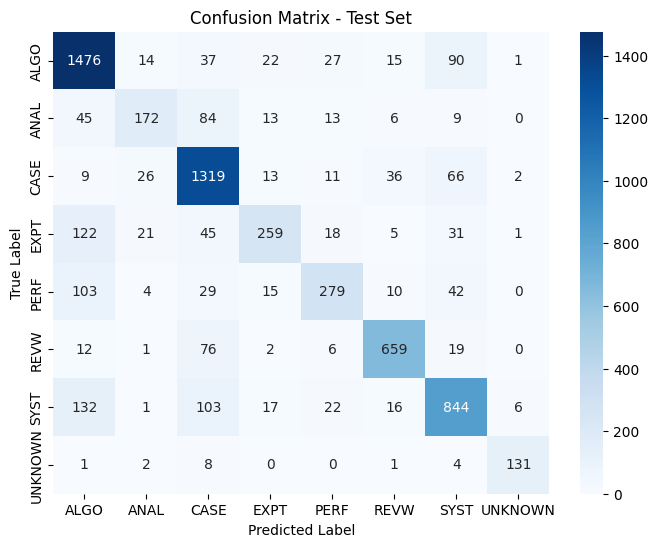


ALGO accuracy: 0.8775

ANAL accuracy: 0.5029

CASE accuracy: 0.8900

EXPT accuracy: 0.5159

PERF accuracy: 0.5788

REVW accuracy: 0.8503

SYST accuracy: 0.7397

UNKNOWN accuracy: 0.8912


In [18]:
# Evaluate best model on test set
test_pred = best_model.predict(X_test_features)
test_pred_proba = best_model.predict_proba(X_test_features)

# Get predictions in original labels
test_pred_labels = label_encoder.inverse_transform(test_pred)

# Calculate metrics
test_accuracy = accuracy_score(y_test, test_pred_labels)
print(f"Test set accuracy: {test_accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, test_pred_labels))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Per-class accuracy
for i, class_name in enumerate(label_encoder.classes_):
    class_mask = y_test == class_name
    class_acc = accuracy_score(y_test[class_mask], test_pred_labels[class_mask])
    print(f"\n{class_name} accuracy: {class_acc:.4f}")

In [15]:
# Analyze misclassifications
misclassified_mask = y_test != test_pred_labels
misclassified_indices = np.where(misclassified_mask)[0]

print(f"Total misclassifications: {len(misclassified_indices)} ({len(misclassified_indices)/len(y_test)*100:.2f}%)")

# Confusion analysis
confusion_pairs = Counter(zip(y_test[misclassified_mask], test_pred_labels[misclassified_mask]))
print("\nMost common confusions (true_label -> predicted_label):")
for (true_label, pred_label), count in confusion_pairs.most_common(5):
    print(f"{true_label} -> {pred_label}: {count} times")

# Sample misclassified examples
print("\nSample misclassified abstracts:")
sample_indices = np.random.choice(misclassified_indices, min(3, len(misclassified_indices)), replace=False)
for i in sample_indices:
    print(f"\nTrue: {y_test[i]}, Predicted: {test_pred_labels[i]}")
    print(f"Confidence: {test_pred_proba[i].max():.3f}")
    print(f"Text preview: {X_test[i][:200]}...")

Total misclassifications: 1414 (21.58%)

Most common confusions (true_label -> predicted_label):
SYST -> ALGO: 132 times
EXPT -> ALGO: 122 times
SYST -> CASE: 103 times
PERF -> ALGO: 103 times
ALGO -> SYST: 90 times

Sample misclassified abstracts:

True: ALGO, Predicted: SYST
Confidence: 0.456
Text preview: stability preserving data-driven models with latent dynamics in this paper, we introduce a data-driven modeling approach for dynamics problems with latent variables. the state-space of the proposed mo...

True: SYST, Predicted: CASE
Confidence: 0.745
Text preview: attracting and retaining oss contributors with a maintainer dashboard tools and artifacts produced by open source software oss have been woven into the foundation of the technology industry. to keep t...

True: PERF, Predicted: CASE
Confidence: 0.519
Text preview: digital transformations of logistics customer service business models the article presents the results of expert surveys conducted by international organization

In [19]:
class MethodologyClassifierPipeline:
    """Production-ready pipeline for detailed methodology classification"""

    def __init__(self):
        self.feature_extractor = None
        self.model = None
        self.label_encoder = None
        self.is_fitted = False

    def fit(self, X, y):
        """Train the complete pipeline"""
        # Initialize components
        self.feature_extractor = OptimizedFeatureExtractor()
        self.label_encoder = LabelEncoder()

        # Encode labels
        y_encoded = self.label_encoder.fit_transform(y)

        # Extract features
        X_features = self.feature_extractor.fit_transform(X)

        # Train model (using best model configuration)
        self.model = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            objective='multi:softprob',
            n_jobs=-1,
            random_state=RANDOM_SEED
        )
        self.model.fit(X_features, y_encoded)

        self.is_fitted = True
        return self

    def predict(self, X):
        """Predict detailed methodologies for new texts"""
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted first")

        # Extract features
        X_features = self.feature_extractor.transform(X)

        # Predict
        predictions = self.model.predict(X_features)

        # Convert to labels
        return self.label_encoder.inverse_transform(predictions)

    def predict_proba(self, X):
        """Get prediction probabilities"""
        if not self.is_fitted:
            raise ValueError("Pipeline must be fitted first")

        X_features = self.feature_extractor.transform(X)
        proba = self.model.predict_proba(X_features)

        # Return as dictionary with class labels
        results = []
        for p in proba:
            result = {}
            for i, class_label in enumerate(self.label_encoder.classes_):
                result[class_label] = float(p[i])
            results.append(result)

        return results

    def classify_single(self, title, abstract):
        """Classify a single paper"""
        # Preprocess
        combined_text = f"{title} {abstract}"
        processed_text = preprocess_text(combined_text)

        # Predict
        prediction = self.predict([processed_text])[0]
        proba = self.predict_proba([processed_text])[0]

        return {
            'detailed_methodology': prediction,
            'confidence': proba[prediction],
            'probabilities': proba
        }

    def save(self, path):
        """Save the pipeline"""
        joblib.dump({
            'feature_extractor': self.feature_extractor,
            'model': self.model,
            'label_encoder': self.label_encoder
        }, path)

    def load(self, path):
        """Load a saved pipeline"""
        components = joblib.load(path)
        self.feature_extractor = components['feature_extractor']
        self.model = components['model']
        self.label_encoder = components['label_encoder']
        self.is_fitted = True
        return self

# Create and train production pipeline
print("Training production pipeline...")
pipeline = MethodologyClassifierPipeline()
pipeline.fit(X_train_aug, y_train_aug)

# Test the pipeline
test_title = "A Survey of Machine Learning Applications in Healthcare"
test_abstract = "This paper presents a comprehensive review of machine learning techniques applied to various healthcare domains through survey methodology..."
result = pipeline.classify_single(test_title, test_abstract)
print(f"\nTest classification:")
print(f"Detailed methodology: {result['detailed_methodology']}")
print(f"Confidence: {result['confidence']:.3f}")
print(f"All probabilities: {result['probabilities']}")

Training production pipeline...

Test classification:
Detailed methodology: UNKNOWN
Confidence: 0.918
All probabilities: {np.str_('ALGO'): 6.442867015721276e-05, np.str_('ANAL'): 5.3444222430698574e-05, np.str_('CASE'): 0.00032822886714711785, np.str_('EXPT'): 2.2011017790646292e-05, np.str_('PERF'): 8.021275425562635e-05, np.str_('REVW'): 0.08119316399097443, np.str_('SYST'): 0.0002724069054238498, np.str_('UNKNOWN'): 0.9179860353469849}


In [20]:
# Create artifacts directory
os.makedirs('methodology_classifier_v9', exist_ok=True)

# Save the production pipeline
pipeline_path = 'methodology_classifier_v9/methodology_pipeline_v9.pkl'
pipeline.save(pipeline_path)
print(f"Pipeline saved to {pipeline_path}")

# Save individual components for analysis
artifacts = {
    'feature_extractor': feature_extractor,
    'model': best_model,
    'label_encoder': label_encoder,
    'training_config': {
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test),
        'augmentation_ratio': 0.5,
        'feature_count': X_train_features.shape[1],
        'best_model': best_model_name,
        'test_accuracy': test_accuracy,
        'cv_mean_accuracy': cv_scores.mean(),
        'timestamp': datetime.now().isoformat()
    }
}

joblib.dump(artifacts, 'methodology_classifier_v9/artifacts_v9.pkl')

# Save performance metrics
with open('methodology_classifier_v9/metrics_v9.txt', 'w') as f:
    f.write(f"Methodology Classifier v7.0 Performance Metrics\n")
    f.write(f"=" * 50 + "\n\n")
    f.write(f"Training date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Dataset size: {len(df)}\n")
    f.write(f"Train/Val/Test split: {len(X_train)}/{len(X_val)}/{len(X_test)}\n")
    f.write(f"Augmented training size: {len(X_train_aug)}\n")
    f.write(f"Feature count: {X_train_features.shape[1]}\n")
    f.write(f"Best model: {best_model_name}\n\n")
    f.write(f"Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}\n")
    f.write(f"Test accuracy: {test_accuracy:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, test_pred_labels))

print("\nAll artifacts saved successfully!")
print(f"\nFinal test accuracy: {test_accuracy:.4f}")
print(f"Expected production accuracy: {cv_scores.mean():.4f} ± {cv_scores.std()*2:.4f}")

Pipeline saved to methodology_classifier_v9/methodology_pipeline_v9.pkl

All artifacts saved successfully!

Final test accuracy: 0.7842
Expected production accuracy: 0.7713 ± 0.0131


In [23]:
# Load and use the saved pipeline
loaded_pipeline = MethodologyClassifierPipeline()
loaded_pipeline.load('methodology_classifier_v9/methodology_pipeline_v9.pkl')

# Example papers to classify
test_papers = [
    {
        'title': 'User Experience Design in Mobile Applications: A Survey Study',
        'abstract': 'We conducted a comprehensive survey of 500 mobile app users to understand their preferences and pain points in user interface design...'
    },
    {
        'title': 'Performance Analysis of Deep Learning Models on GPU Clusters',
        'abstract': 'This paper presents quantitative benchmarks comparing various deep learning frameworks on distributed GPU systems, measuring throughput and latency...'
    },
    {
        'title': 'Digital Transformation Success Factors: A Mixed Methods Study',
        'abstract': 'We employed both surveys and in-depth interviews to investigate how organizations successfully implement digital transformation initiatives...'
    }
]

print("Example classifications:\n")
for paper in test_papers:
    result = loaded_pipeline.classify_single(paper['title'], paper['abstract'])
    print(f"Title: {paper['title']}")
    print(f"Predicted: {result['detailed_methodology']} (confidence: {result['confidence']:.3f})")
    print(f"All probabilities: {result['probabilities']}")
    print("-" * 50)

Example classifications:

Title: User Experience Design in Mobile Applications: A Survey Study
Predicted: UNKNOWN (confidence: 0.999)
All probabilities: {np.str_('ALGO'): 1.41370337587432e-05, np.str_('ANAL'): 1.7678759832051583e-05, np.str_('CASE'): 0.00046392271178774536, np.str_('EXPT'): 2.497526293154806e-05, np.str_('PERF'): 1.6746695109759457e-05, np.str_('REVW'): 0.0001601508993189782, np.str_('SYST'): 0.00012397626414895058, np.str_('UNKNOWN'): 0.9991783499717712}
--------------------------------------------------
Title: Performance Analysis of Deep Learning Models on GPU Clusters
Predicted: UNKNOWN (confidence: 0.987)
All probabilities: {np.str_('ALGO'): 0.00015560539031866938, np.str_('ANAL'): 0.00055458873976022, np.str_('CASE'): 0.0001287144550587982, np.str_('EXPT'): 7.751633529551327e-05, np.str_('PERF'): 0.0114818150177598, np.str_('REVW'): 0.00011865174019476399, np.str_('SYST'): 0.0002900016261264682, np.str_('UNKNOWN'): 0.9871930480003357}
----------------------------

In [24]:
# Save to Google Drive
!cp -r methodology_classifier_v9 "/content/drive/MyDrive/"
print("✓ Files saved to your Google Drive!")

# Create zip for download
import zipfile

with zipfile.ZipFile('methodology_classifier_v9.zip', 'w') as zipf:
    for root, dirs, files_in_dir in os.walk('methodology_classifier_v9'):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path)
            zipf.write(file_path, arcname)

# Download
from google.colab import files
files.download('methodology_classifier_v9.zip')

print("\n✓ Download started!")

✓ Files saved to your Google Drive!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ Download started!
